# Importamos las librerias para el EDA

Definimos las columnas, están en base al archivo adult.names

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

pd.set_option("display.max_columns", None)

# Cargamos los datos

In [29]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

In [30]:
df = pd.read_csv(
    "../data/raw/adult.data",
    header=None,
    names=columns
)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# Tamaño del dataframe

In [31]:
print('Filas: ', df.shape[0])
print('columnas', df.shape[1])

Filas:  32561
columnas 15


# Información 

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# Estadísticas

In [33]:
df.describe(include='all')

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


# Datos sucios
De acuerdo a la teoria, los datos sucios son: 
- Valores faltantes
- Duplicados
- Tipos incorrectos
- Outliers
- Errores estructurales


# Valores faltantes

In [34]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Puedes que los valores faltantes sean 0s porque los datos pueden estar representados con ?

# Buscamos '?'

In [35]:
for col in df.select_dtypes(include="object").columns:
    count = (df[col] == " ?").sum()
    if count > 0:
        print(f"{col}: {count}")

workclass: 1836
occupation: 1843
native-country: 583


# Buscamos duplicados

In [36]:
print('Duplicados exactos: ', df.duplicated().sum())

Duplicados exactos:  24


# Tipos de datos

Revisamos los tipos de datos de cada variable para identificar posibles
inconsistencias entre el tipo almacenado y la naturaleza de la variable.

In [37]:
# Tipos de datos de cada columna
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

In [38]:
# Para verlo más ordenado 
pd.DataFrame({
    "columna": df.columns,
    "tipo": df.dtypes.astype(str)
})

,columna,tipo
age,age,int64
workclass,workclass,object
fnlwgt,fnlwgt,int64
education,education,object
education-num,education-num,int64
marital-status,marital-status,object
occupation,occupation,object
relationship,relationship,object
race,race,object
sex,sex,object


In [39]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(10))


workclass
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

education
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
Name: count, dtype: int64

marital-status
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

occupation
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295

### Conclusión

No se identificaron tipos de datos evidentemente incorrectos.
Las variables numéricas están almacenadas como tipos numéricos y las
variables categóricas como `object`. 

Aunque `income` es de tipo `object`, esto es correcto porque representa
una variable categórica que contiene las clases `<=50K` y `>50K`.

# Detección de outliers

Analizamos las variables numéricas mediante el rango intercuartílico (IQR)
para identificar valores que se encuentran alejados de la distribución central.

In [40]:
# Variables numéricas
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    print(f"{col}: {outliers} outliers")

age: 143 outliers
fnlwgt: 992 outliers
education-num: 1198 outliers
capital-gain: 2712 outliers
capital-loss: 1519 outliers
hours-per-week: 9008 outliers


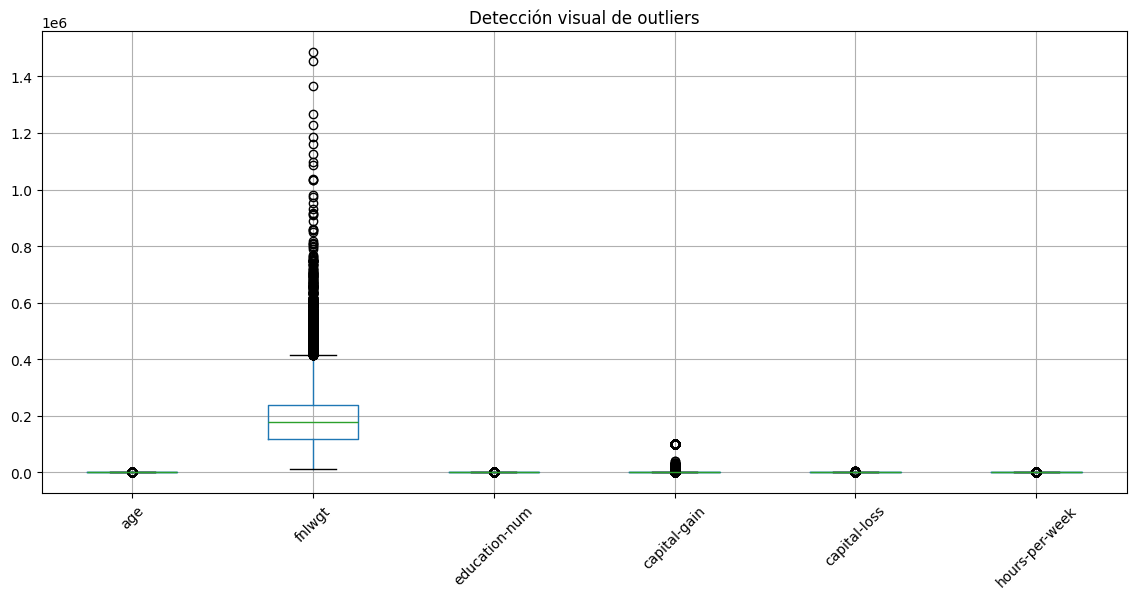

In [41]:
import matplotlib.pyplot as plt

df[numeric_cols].boxplot(figsize=(14, 6))
plt.xticks(rotation=45)
plt.title("Detección visual de outliers")
plt.show()

### Conclusión

Se identificaron valores potencialmente atípicos en algunas variables
numéricas mediante el método del IQR. Sin embargo, la detección de un
outlier no implica necesariamente que el dato sea incorrecto.

Por ello, estos valores serán conservados durante esta etapa y se
analizará posteriormente si corresponden a observaciones válidas o a
errores de registro.

# Errores estructurales

Revisamos las variables categóricas para identificar inconsistencias
en la forma en que se representan los valores.

In [42]:
# Valores con espacios al inicio o al final
for col in df.select_dtypes(include="object").columns:
    espacios = df[col].astype(str).str.contains(
        r"^\s|\s$", regex=True
    ).sum()
    
    print(f"{col}: {espacios} valores con espacios")

workclass: 32561 valores con espacios
education: 32561 valores con espacios
marital-status: 32561 valores con espacios
occupation: 32561 valores con espacios
relationship: 32561 valores con espacios
race: 32561 valores con espacios
sex: 32561 valores con espacios
native-country: 32561 valores con espacios
income: 32561 valores con espacios


# Target 

In [43]:
print(df['income'].value_counts(dropna=False))

income
<=50K    24720
>50K      7841
Name: count, dtype: int64


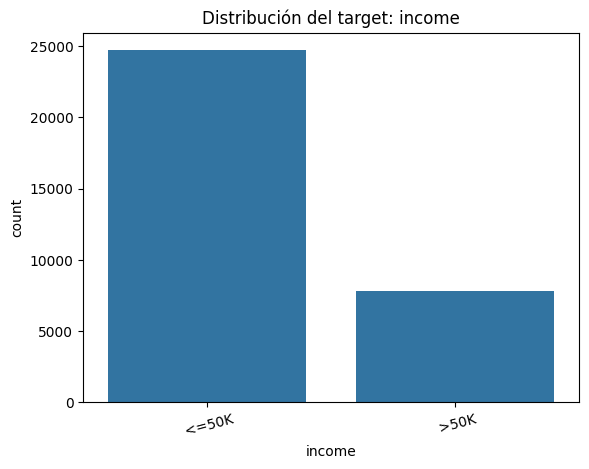

In [44]:
sns.countplot(data=df, x='income')
plt.title('Distribución del target: income')
plt.xticks(rotation=15)
plt.show()

# MCAR

In [ ]:
# Convertimos '?' en valores faltantes
df_missing = df.replace(' ?', np.nan)  
#OJO: LOS FALTANTES VIENEN COMO ' ?', no como '?'

# Revisamos los valores faltantes
df_missing.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

### Creamos una variable que indique si falta occupation

In [46]:
df_missing['occupation_missing'] = df_missing['occupation'].isna()

In [47]:
pd.crosstab(
    df_missing['income'],
    df_missing['occupation_missing'],
    normalize='index'
) * 100

occupation_missing,False,True
income,,
<=50K,93.317152,6.682848
>50K,97.564086,2.435914


In [48]:
pd.crosstab(
    df_missing['sex'],
    df_missing['occupation_missing'],
    normalize='index'
) * 100

occupation_missing,False,True
sex,,
Female,92.191997,7.808003
Male,95.401560,4.598440


In [49]:
pd.crosstab(
    df_missing['education'],
    df_missing['occupation_missing'],
    normalize='index'
) * 100

occupation_missing,False,True
education,,
10th,89.067524,10.932476
11th,89.872340,10.127660
12th,90.762125,9.237875
1st-4th,92.857143,7.142857
5th-6th,90.990991,9.009009
7th-8th,88.699690,11.300310
9th,90.077821,9.922179
Assoc-acdm,95.595127,4.404873
Assoc-voc,95.586107,4.413893


### MCAR

Se comparó la presencia de valores faltantes en `occupation`
entre diferentes categorías observadas como `income`, `sex` y
`education`.

Estas comparaciones permiten evaluar si la ausencia parece
independiente de variables observadas. Sin embargo, con este
análisis no es posible demostrar que los datos sean MCAR.

# MAR
Ahora queremos comprobar si la ausencia de un dato está relacionada con otra variable que sí observamos

In [50]:
pd.crosstab(
    df_missing['workclass'].isna(),
    df_missing['occupation'].isna(),
    normalize='index'
) * 100

occupation,False,True
workclass,,
False,99.977217,0.022783
True,0.000000,100.000000


In [51]:
pd.crosstab(
    df_missing['income'],
    df_missing['workclass'].isna(),
    normalize='index'
) * 100

workclass,False,True
income,,
<=50K,93.345469,6.654531
>50K,97.564086,2.435914


In [52]:
pd.crosstab(
    df_missing['education'],
    df_missing['occupation'].isna(),
    normalize='index'
) * 100

occupation,False,True
education,,
10th,89.067524,10.932476
11th,89.872340,10.127660
12th,90.762125,9.237875
1st-4th,92.857143,7.142857
5th-6th,90.990991,9.009009
7th-8th,88.699690,11.300310
9th,90.077821,9.922179
Assoc-acdm,95.595127,4.404873
Assoc-voc,95.586107,4.413893


Se analizaron los valores faltantes de `occupation` y `workclass`
en función de variables observadas como `education` e `income`.

### MNAR

MNAR ocurre cuando la probabilidad de que un dato falte depende
del propio valor no observado.

En este dataset no es posible demostrar estadísticamente que los
valores faltantes sean MNAR, porque el valor que debería permitir
identificar el mecanismo no está disponible.

Por ello, una hipótesis de MNAR tendría que fundamentarse en
conocimiento del dominio y no únicamente en la información observada.